# Getting Started

## Required Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

## Importing Dataframe

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# EDA

## Gather Information

### Count of Rows and Columns

In [5]:
df.shape

(1338, 7)

### First 5 entries

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Data Types of Each Column

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


### Stats of Each Column

In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


### Check for null entries in each column

In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Visualization

### For Numerical Data

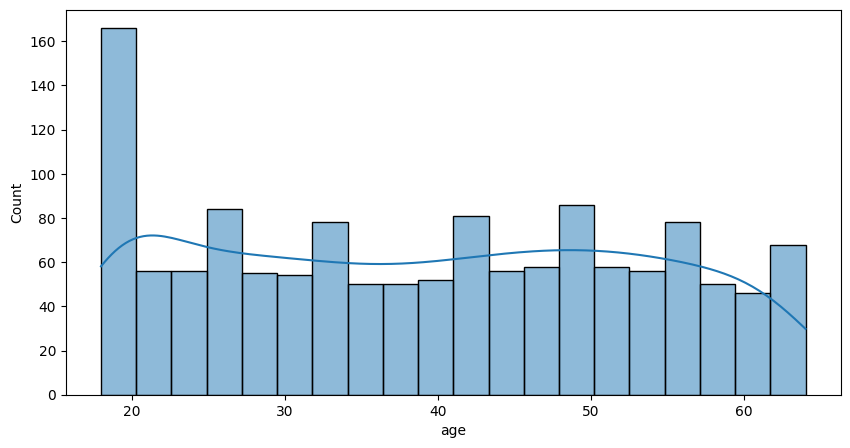

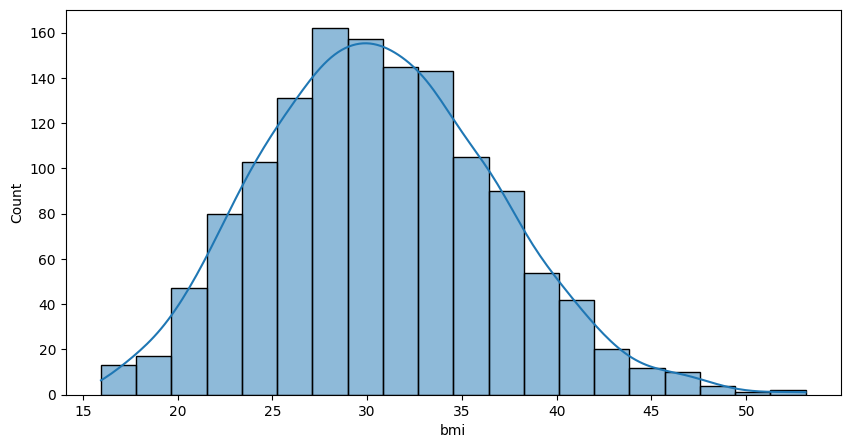

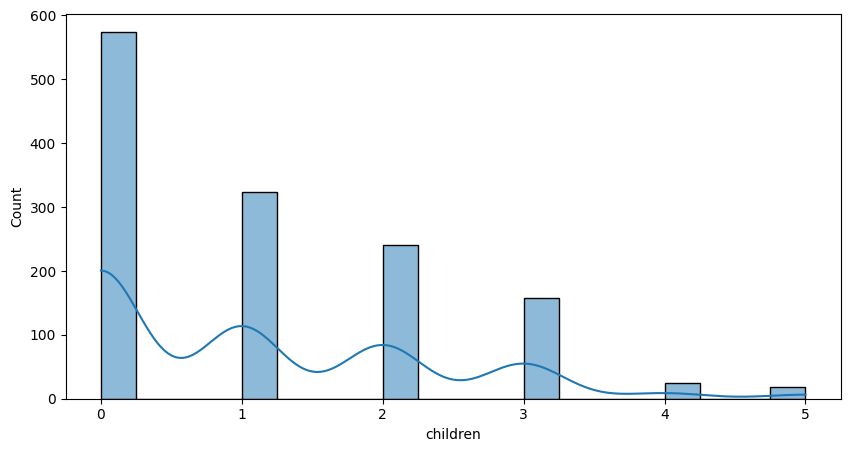

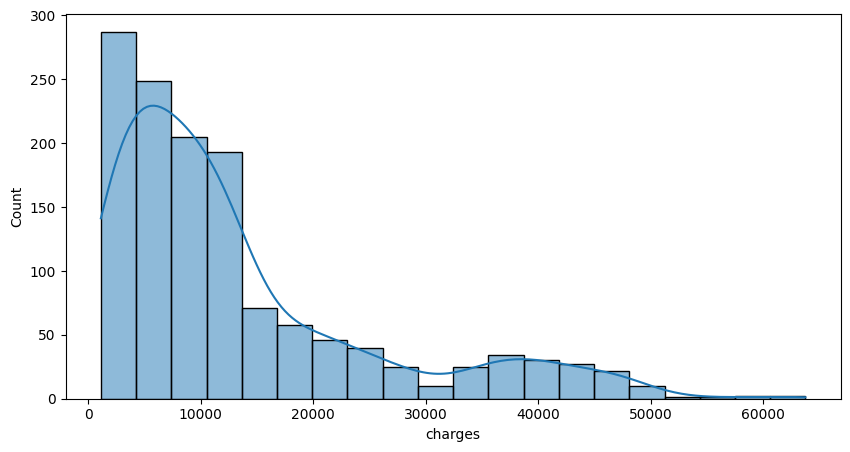

In [10]:
numeric_columns = ['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=20)

### For Categorical Data

<Axes: xlabel='children', ylabel='count'>

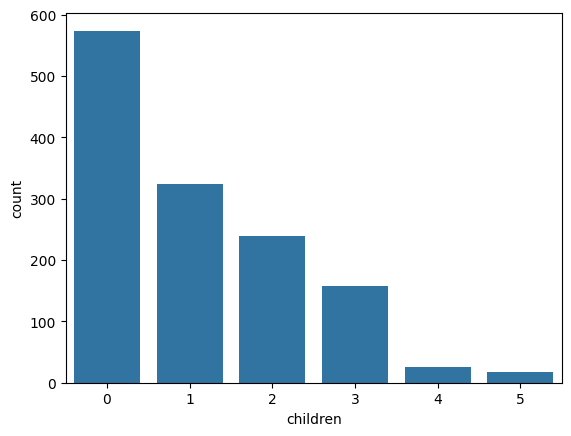

In [11]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

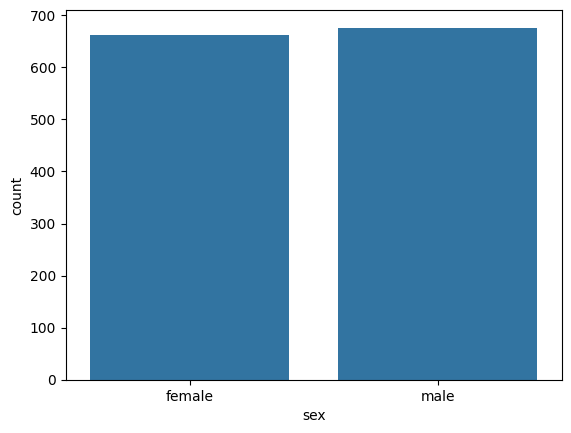

In [12]:
sns.countplot(x = df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

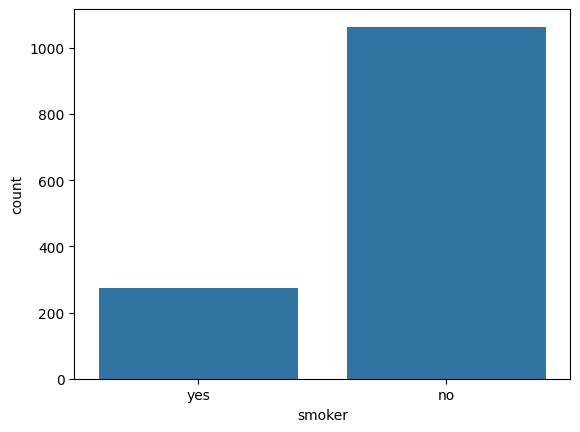

In [13]:
sns.countplot(x = df['smoker'])

### Relating Input with Output

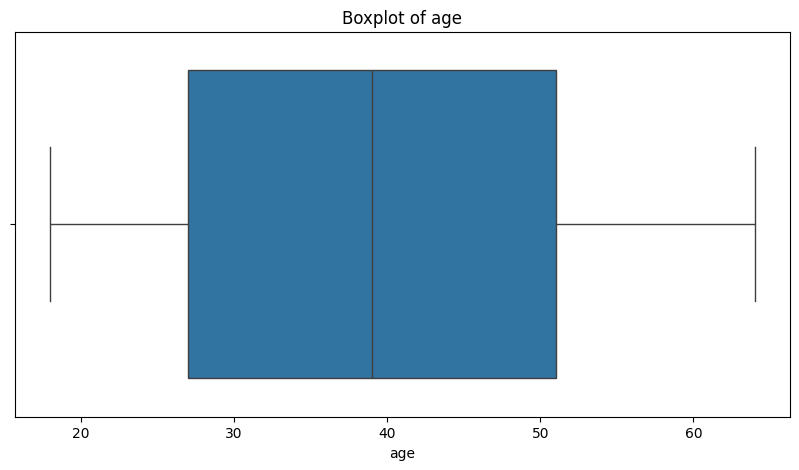

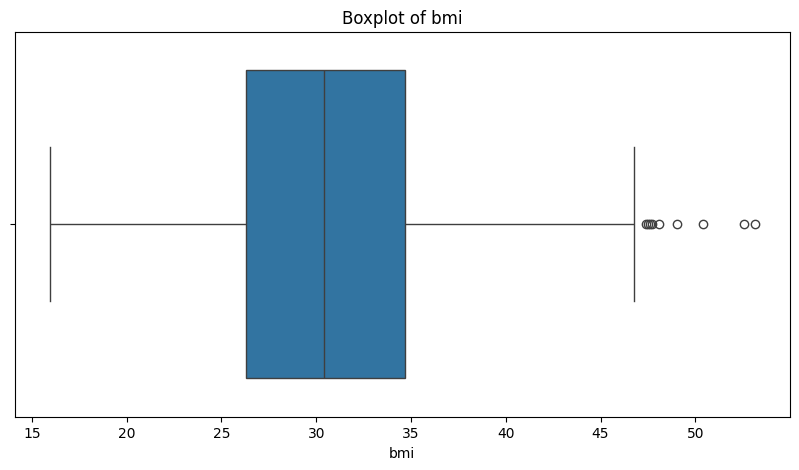

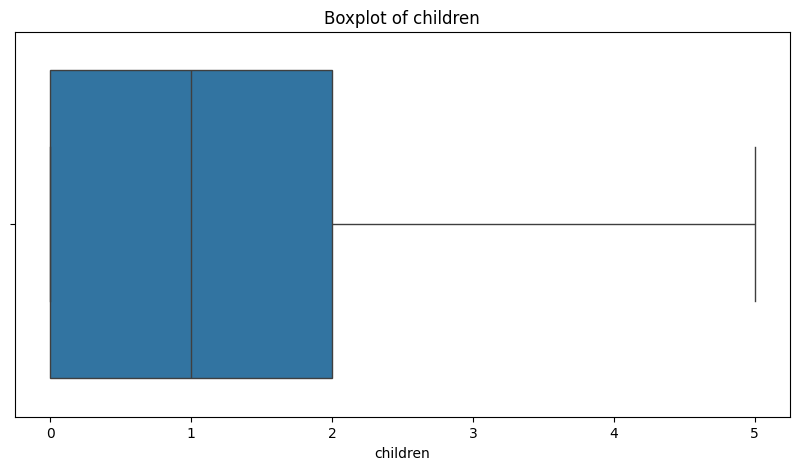

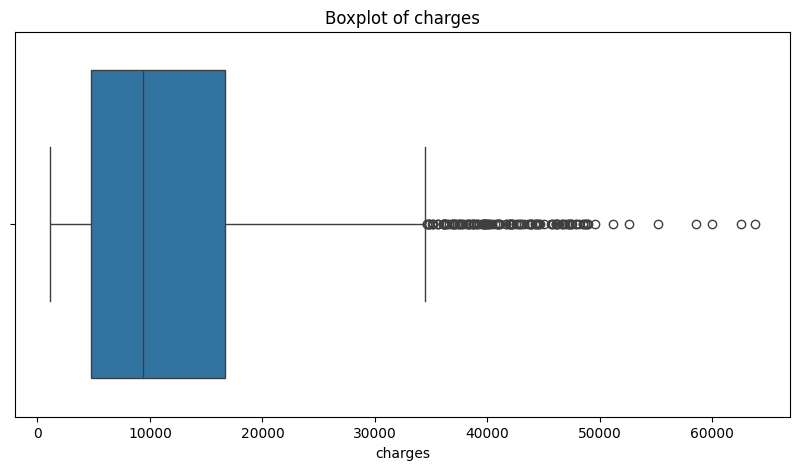

In [14]:
for col in numeric_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### For Correlation

<Axes: >

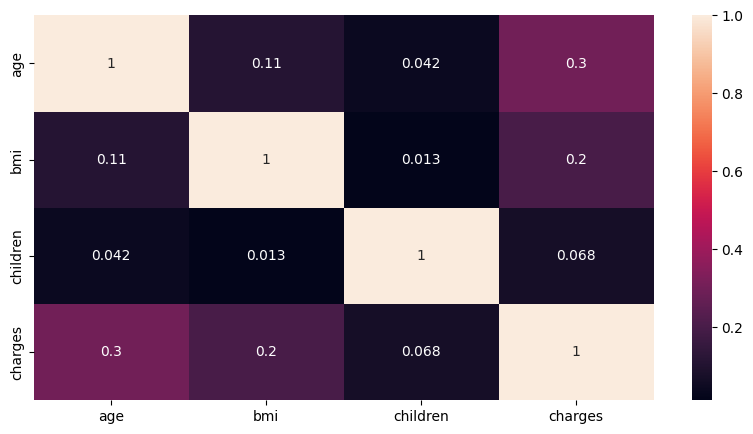

In [15]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data Cleaning and Preprocessing

## Creating Copy

In [16]:
df_cleaned = df.copy()

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Removing Duplicates

In [18]:
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned.shape

(1337, 7)

## Removing Nulls (if any)

In [20]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

## Label Encoding

In [22]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [23]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male": 0, "female": 1})

In [24]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [25]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [26]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no": 0, "yes": 1})

#### Renaming

In [27]:
df_cleaned.rename(columns={
    'smoker': 'is_smoker',
    'sex': 'is_female'
    }, inplace=True)

In [28]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


## One-Hot Encoding

In [29]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['region'], drop_first=True)

In [30]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


In [31]:
df_cleaned =df_cleaned.astype(int)

In [32]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0


# Feature Enggineering and Extraction

<Axes: xlabel='bmi', ylabel='Count'>

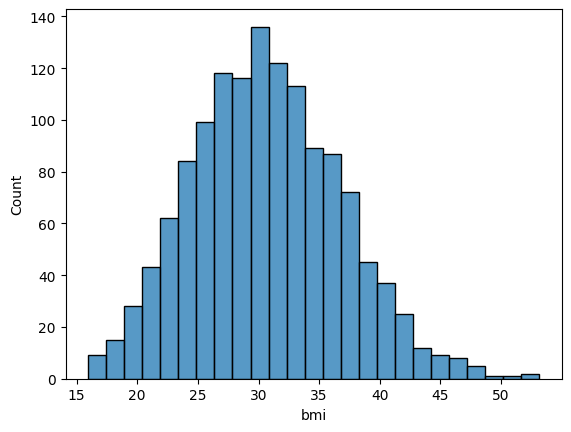

In [33]:
sns.histplot(df['bmi'])

## Feature Engg.

In [34]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0, 18.5, 24.9, 29.9, float('inf')],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

In [35]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overweight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overweight


In [36]:
df_cleaned = pd.get_dummies(df_cleaned,columns=['bmi_category'], drop_first=True)

In [37]:
df_cleaned = df_cleaned.astype(int)

In [38]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


### Scaling

In [39]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

In [40]:
from sklearn.preprocessing import StandardScaler
cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [41]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,0,1,0


## Feature Extraction

In [42]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'],
      dtype='object')

### Pearson Correlation

In [43]:
import pandas as pd

# Define columns
columns = ['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
           'region_northwest', 'region_southeast', 'region_southwest',
           'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese']

# Compute correlation matrix
correlation_matrix = df_cleaned[columns].corr(method='pearson')

# Extract and sort correlation with 'charges'
charges_corr = correlation_matrix['charges'].drop('charges').sort_values(ascending=False)

# Format as DataFrame
charges_corr_df = charges_corr.reset_index()
charges_corr_df.columns = ['Feature', 'Pearson Correlation']

# Display
print(charges_corr_df)

                    Feature  Pearson Correlation
0                 is_smoker             0.787234
1                       age             0.298309
2        bmi_category_Obese             0.200348
3                       bmi             0.196236
4          region_southeast             0.073577
5                  children             0.067390
6          region_northwest            -0.038695
7          region_southwest            -0.043637
8                 is_female            -0.058046
9       bmi_category_Normal            -0.104042
10  bmi_category_Overweight            -0.120601


### Chi Square Test

In [46]:
import pandas as pd
from scipy.stats import chi2_contingency

# Step 1: Create quantile-based bins for 'charges'
df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

# Step 2: Define categorical features
cat_features = [
    'is_female',
    'is_smoker',
    'region_northwest',
    'region_southeast',
    'region_southwest',
    'bmi_category_Normal',
    'bmi_category_Overweight',
    'bmi_category_Obese'
]

# Step 3: Perform Chi-square test for each categorical feature
chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = "Reject Null (Keep Feature)" if p_val < 0.05 else "Accept Null (Drop Feature)"    
    chi2_results[col] = {
        'Chi2 Statistic': chi2_stat,
        'p-value': p_val,
        'Decision': decision
    }

# Step 4: Show results in a DataFrame sorted by p-value
chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p-value')
print(chi2_df)

                        Chi2 Statistic   p-value                    Decision
is_smoker                   848.219178       0.0  Reject Null (Keep Feature)
region_southeast             15.998167  0.001135  Reject Null (Keep Feature)
is_female                    10.258784   0.01649  Reject Null (Keep Feature)
bmi_category_Obese            8.515711  0.036473  Reject Null (Keep Feature)
region_southwest              5.091893  0.165191  Accept Null (Drop Feature)
bmi_category_Overweight        4.25149  0.235557  Accept Null (Drop Feature)
bmi_category_Normal           3.708088   0.29476  Accept Null (Drop Feature)
region_northwest               1.13424  0.768815  Accept Null (Drop Feature)


In [47]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese',
       'charges_bin'],
      dtype='object')

## Dropping unnecessary features

In [50]:
# Columns to drop
cols_to_drop = [
    'region_southwest',
    'bmi_category_Overweight',
    'bmi_category_Normal',
    'region_northwest',
    'charges_bin'
]

# Create the final DataFrame
final_df = df_cleaned.drop(columns=cols_to_drop)

# Optional: Check final columns
print(final_df.columns)


Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_southeast', 'bmi_category_Obese'],
      dtype='object')


# Final Dataframe

In [51]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_Obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0
1,-1.511647,0,0.462463,-0.079442,0,1725,1,1
2,-0.799350,0,0.462463,1.580143,0,4449,1,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,0
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
